<a href="https://colab.research.google.com/github/DebDDash/Suicide_Discourse_Inidan_Institutions/blob/main/Suicide_Rate_Based_Classification_IPD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Iterated Prisoner's Dilemma on IIT Suicide Reddit Data
## CGS616: Human Centered Computing

---

## Hypothesis

Online discourse around student suicides is not uniformly cooperative or hostile —
it is an emergent outcome of **repeated strategic interactions** between users.

- **Overall:** Early discourse is dominated by accusation and information-seeking (low cooperation);
  over time, sympathy and personal reflection increase (rising cooperation).
- A single "blame-maximising" account (AD) cannot permanently destabilise a
  community trending toward empathy.
- Scale-free network structure (a few high-upvote accounts have outsized reach)
  amplifies whichever strategy occupies the hub.
- Forgiving strategies (GTFT) are more resilient than strict punishment (Grim Trigger)
  in this emotionally charged, noisy environment.

---

## Key Adaptation from Assignment 2

In Assignment 2 we modelled behavior via an IOHMM — transitions between latent
collective states driven by incident salience.

Here, **the same transitions are reframed as outcomes of dyadic interactions**:
P(C→C), P(C→D), P(D→C), P(D→D) are now driven by *who replies to whom* and *what
each user's response strategy is*, rather than only internal stochastic changes.

This shifts the interpretation from **individual state modelling** to
**interaction-driven emergence of cooperation**.

---

## C / D Mapping for Suicide Discourse

| Category | Behavior | Rationale |
|----------|----------|-----------|
| S1 Sympathy & Support | **C** | prosocial, emotionally supportive |
| S2 Information Sharing | **C** | factual, constructive |
| S3 Speculation / Cause | **C** | seeks understanding, not blame |
| S5 Mobilization / Action | **C** | collective action, systemic concern |
| S8 Personal Reflection | **C** | vulnerable sharing, opens dialogue |
| S9 Institutional / Policy | **C** | solution-oriented |
| S4 Accusation / Blame | **D** | adversarial, escalates conflict |
| S6 Indifference / Low-effort | **D** | dismissive, disengages community |
| S7 Irrelevant | **D** | noise, derails discourse |


In [ ]:
!pip install pandas numpy matplotlib networkx scipy


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from scipy.special import rel_entr
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)


COOP_CATS   = {"S1", "S2", "S3", "S5", "S8", "S9"}
DEFECT_CATS = {"S4", "S6", "S7"}


INSTITUTION_ANCHORS = {
    "BITS":          pd.Timestamp("2025-03-03"),
    "IIT Bombay":    pd.Timestamp("2026-02-02"),
    "IIT Delhi":     pd.Timestamp("2026-03-09"),
    "IIT Kanpur":    pd.Timestamp("2025-12-29"),
    "IIT Kharagpur": pd.Timestamp("2026-04-13"),
    "VIT":           pd.Timestamp("2025-07-17"),
}


In [ ]:

SUICIDE_COUNTS = {
    "IIT Bombay":    {"2014_2019": 7, "2019_2024": 2},
    "IIT Delhi":     {"2014_2019": 4, "2019_2024": 6},
    "IIT Kanpur":    {"2014_2019": 1, "2019_2024": 3},
    "IIT Kharagpur": {"2014_2019": 5, "2019_2024": 3},
    "BITS":          {"2014_2019": 0, "2019_2024": 0},
    "VIT":           {"2014_2019": 0, "2019_2024": 0},
}

GROUP_LABELS = {
    "IIT Bombay":    "HIGH",
    "IIT Delhi":     "LOW",
    "IIT Kanpur":    "HIGH",
    "IIT Kharagpur": "HIGH",
    "BITS":          "LOW",
    "VIT":           "LOW",
}

In [ ]:
HIGH_INSTS = [k for k, v in GROUP_LABELS.items() if v == "HIGH"]
LOW_INSTS  = [k for k, v in GROUP_LABELS.items() if v == "LOW"]

TIME_BINS   = [-7.01, 3, 14, 30, 180]
TIME_LABELS = ["Acute\n(0-3d)", "Active\n(4-14d)", "Absorbed\n(15-30d)", "Recovery\n(31d+)"]

R, T, P_pay, S = 3, 5, 1, 0


N_AGENTS      = 100
N_ROUNDS      = 10
N_GENERATIONS = 50


In [ ]:

COLORS = {
    "AC":"#2ecc71","AD":"#e74c3c","TFT":"#3498db",
    "TF2T":"#9b59b6","GTFT":"#f39c12","GT":"#1abc9c",
    "C":"#27ae60","D":"#c0392b",
}
GROUP_COLORS = {"HIGH":"#e74c3c","LOW":"#1abc9c"}
INST_COLORS  = {
    "BITS":"#e74c3c","IIT Bombay":"#3498db","IIT Delhi":"#f39c12",
    "IIT Kanpur":"#2ecc71","IIT Kharagpur":"#9b59b6","VIT":"#1abc9c",
}

plt.rcParams.update({
    "font.family":"DejaVu Sans",
    "axes.spines.top":False,"axes.spines.right":False,
    "figure.facecolor":"#0f1117","axes.facecolor":"#1a1d27",
    "axes.labelcolor":"#e0e0e0","xtick.color":"#aaaaaa",
    "ytick.color":"#aaaaaa","text.color":"#e0e0e0",
    "axes.titlecolor":"#ffffff","grid.color":"#2a2d3a","grid.alpha":0.5,
})

In [ ]:
def _ax_style(ax, title="", xlabel="", ylabel=""):
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(True, alpha=0.3)

print("Setup complete.")
print(f"HIGH: {HIGH_INSTS}")
print(f"LOW : {LOW_INSTS}")
print()
print("Suicide counts driving the grouping:")
for inst, counts in SUICIDE_COUNTS.items():
    total = counts["2014_2019"] + counts["2019_2024"]
    print(f"  {inst:<18}  2014-19:{counts['2014_2019']}  2019-24:{counts['2019_2024']}"
          f"  total:{total:2d}  -> {GROUP_LABELS[inst]}")

Setup complete.
HIGH: ['IIT Bombay', 'IIT Kanpur', 'IIT Kharagpur']
LOW : ['IIT Delhi', 'BITS', 'VIT']

Suicide counts driving the grouping:
  IIT Bombay          2014-19:7  2019-24:2  total: 9  -> HIGH
  IIT Delhi           2014-19:4  2019-24:6  total:10  -> LOW
  IIT Kanpur          2014-19:1  2019-24:3  total: 4  -> HIGH
  IIT Kharagpur       2014-19:5  2019-24:3  total: 8  -> HIGH
  BITS                2014-19:0  2019-24:0  total: 0  -> LOW
  VIT                 2014-19:0  2019-24:0  total: 0  -> LOW


# 1. DATA LOADING & INTERACTION GRAPH

In [ ]:

df_raw = pd.read_csv("reddit_categorised.csv")
df_raw["datetime"]    = pd.to_datetime(df_raw["created_utc"], unit="s")
df_raw["institution"] = df_raw["institution"].astype(str).str.strip()
df_raw["comment_id"]  = df_raw["comment_id"].astype(str)
df_raw["parent_id"]   = df_raw["parent_id"].astype(str)
df_raw["behavior"]    = df_raw["category_code"].apply(
    lambda x: "C" if x in COOP_CATS else "D"
)

rows = []
for inst, anchor in INSTITUTION_ANCHORS.items():
    grp = df_raw[df_raw["institution"] == inst].copy()
    grp["days_since"] = (grp["datetime"] - anchor).dt.total_seconds() / 86400
    grp = grp[(grp["days_since"] >= -7) & (grp["days_since"] <= 180)]
    rows.append(grp)

df = pd.concat(rows).reset_index(drop=True)
df["time_bin"] = pd.cut(df["days_since"], bins=TIME_BINS, labels=TIME_LABELS)
df = df.dropna(subset=["time_bin"])
df["time_bin"] = pd.Categorical(df["time_bin"], categories=TIME_LABELS, ordered=True)
df["group"]    = df["institution"].map(GROUP_LABELS)

id_to_behavior = dict(zip(df["comment_id"], df["behavior"]))
interactions   = df[df["parent_id"].isin(id_to_behavior)].copy()
interactions["parent_behavior"] = interactions["parent_id"].map(id_to_behavior)

print(f"\nTotal comments  : {len(df):,}")
print(f"Reply pairs     : {len(interactions):,}")
print("\nComments by group:")
print(df["group"].value_counts())
print("\nC fraction by group:")
print(df.groupby("group")["behavior"].apply(lambda x:(x=="C").mean()).round(3))




Total comments  : 2,297
Reply pairs     : 899

Comments by group:
group
HIGH    1727
LOW      570
Name: count, dtype: int64

C fraction by group:
group
HIGH    0.490
LOW     0.495
Name: behavior, dtype: float64


# 2. TRANSITION MATRICES

In [ ]:

def compute_observed_transitions(df_sub, interactions_sub):
    freq_per_bin, trans_per_bin = {}, {}
    for b in TIME_LABELS:
        sub = df_sub[df_sub["time_bin"] == b]
        if len(sub) == 0:
            continue
        c_frac = (sub["behavior"] == "C").mean()
        freq_per_bin[b] = {"C": c_frac, "D": 1 - c_frac}
        int_sub = interactions_sub[interactions_sub["time_bin"] == b]
        counts  = np.zeros((2, 2))
        idx_map = {"C": 0, "D": 1}
        for _, row in int_sub.iterrows():
            p, c = row["parent_behavior"], row["behavior"]
            if p in idx_map and c in idx_map:
                counts[idx_map[p], idx_map[c]] += 1
        rs = counts.sum(axis=1, keepdims=True)
        rs[rs == 0] = 1
        trans_per_bin[b] = counts / rs
    return freq_per_bin, trans_per_bin

def kl_divergence(p_mat, q_mat):
    p = p_mat.flatten() + 1e-9
    q = q_mat.flatten() + 1e-9
    p /= p.sum(); q /= q.sum()
    return float(np.sum(rel_entr(p, q)) + np.sum(rel_entr(q, p))) / 2

overall_freq, overall_trans = compute_observed_transitions(df, interactions)

group_freq, group_trans = {}, {}
for grp_name in ["HIGH","LOW"]:
    df_g  = df[df["group"] == grp_name]
    int_g = interactions[interactions["group"] == grp_name]
    group_freq[grp_name], group_trans[grp_name] = compute_observed_transitions(df_g, int_g)

inst_freq, inst_trans = {}, {}
for inst in INSTITUTION_ANCHORS:
    df_i  = df[df["institution"] == inst]
    int_i = interactions[interactions["institution"] == inst]
    if len(df_i) < 30:
        continue
    inst_freq[inst], inst_trans[inst] = compute_observed_transitions(df_i, int_i)

print("\nGroup C fractions per phase:")
for grp_name in ["HIGH","LOW"]:
    print(f"  [{grp_name}]")
    for b, frac in group_freq[grp_name].items():
        print(f"    {b:22s}  C={frac['C']:.3f}  D={frac['D']:.3f}")


Group C fractions per phase:
  [HIGH]
    Acute
(0-3d)            C=0.530  D=0.470
    Active
(4-14d)          C=0.487  D=0.513
    Absorbed
(15-30d)       C=0.449  D=0.551
    Recovery
(31d+)         C=0.345  D=0.655
  [LOW]
    Acute
(0-3d)            C=0.463  D=0.537
    Active
(4-14d)          C=0.547  D=0.453
    Recovery
(31d+)         C=0.444  D=0.556


# FIGURE 1 - COOPERATION TREND

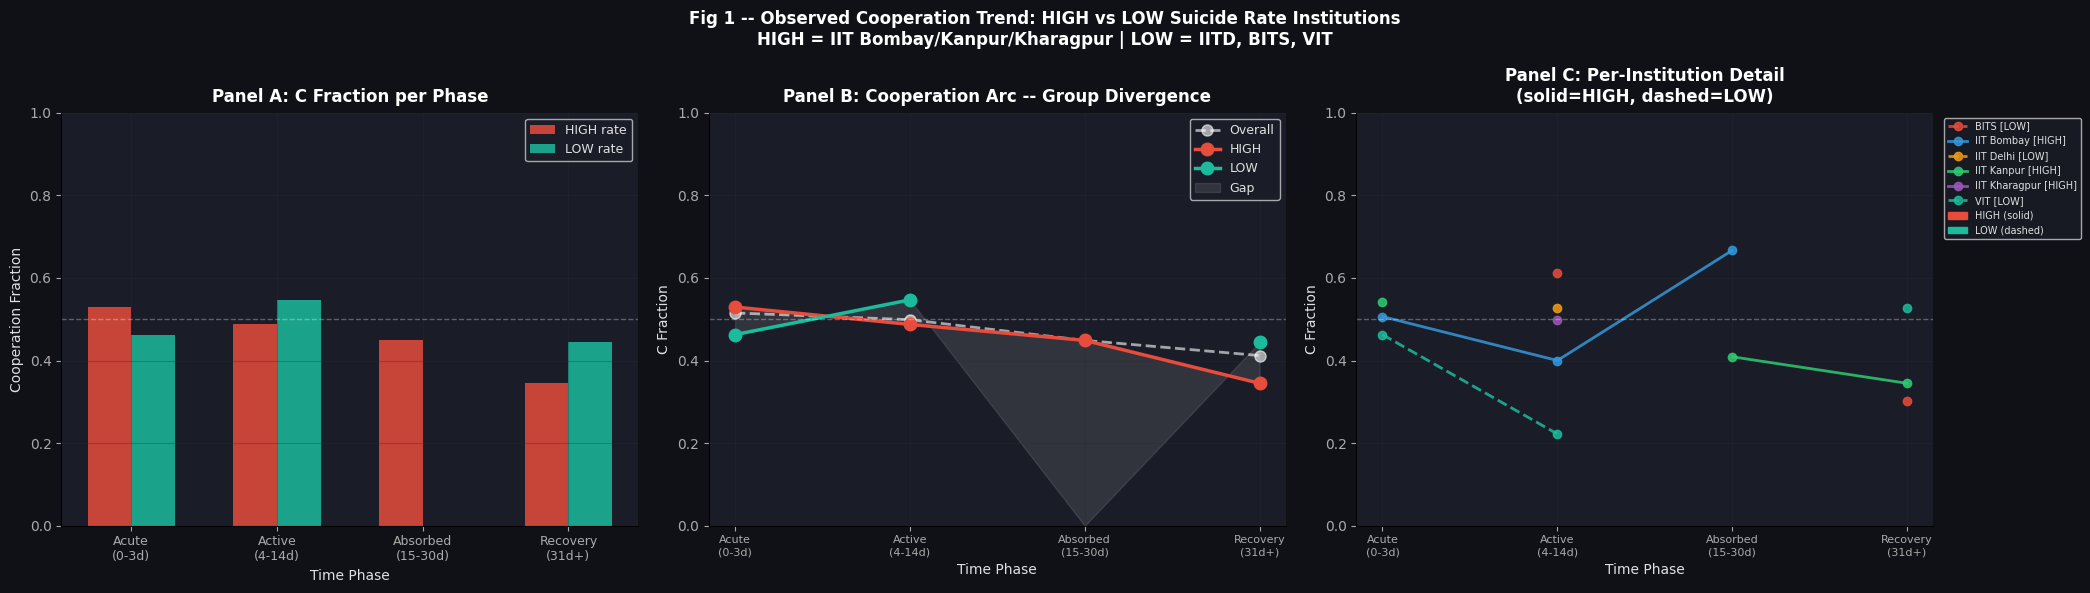

Figure 1 saved.


In [ ]:

gens = list(range(N_GENERATIONS))

fig, axes = plt.subplots(1, 3, figsize=(21, 6), facecolor="#0f1117")
fig.suptitle(
    "Fig 1 -- Observed Cooperation Trend: HIGH vs LOW Suicide Rate Institutions\n"
    "HIGH = IIT Bombay/Kanpur/Kharagpur | LOW = IITD, BITS, VIT",
    fontsize=12, fontweight="bold", color="white"
)
fig.patch.set_facecolor("#0f1117")

# Panel A: grouped bars
ax = axes[0]; ax.set_facecolor("#1a1d27")
x = np.arange(len(TIME_LABELS)); w = 0.30
for gi, grp_name in enumerate(["HIGH","LOW"]):
    c_vals = [group_freq[grp_name].get(b,{"C":0})["C"] for b in TIME_LABELS]
    ax.bar(x+(gi-0.5)*w, c_vals, w, label=f"{grp_name} rate",
           color=GROUP_COLORS[grp_name], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(TIME_LABELS, fontsize=9)
ax.set_ylim(0,1); ax.axhline(0.5,ls="--",color="white",alpha=0.3,lw=1)
ax.legend(fontsize=9); _ax_style(ax,"Panel A: C Fraction per Phase","Time Phase","Cooperation Fraction")

# Panel B: arcs
ax2 = axes[1]; ax2.set_facecolor("#1a1d27")
ob = [b for b in TIME_LABELS if b in overall_freq]
oc = [overall_freq[b]["C"] for b in ob]
ax2.plot(range(len(ob)),oc,"o--",lw=2,color="white",markersize=8,label="Overall",alpha=0.6)
for grp_name in ["HIGH","LOW"]:
    vals = [group_freq[grp_name].get(b,{"C":np.nan})["C"] for b in TIME_LABELS]
    ax2.plot(range(len(TIME_LABELS)),vals,"o-",lw=2.5,markersize=9,
             color=GROUP_COLORS[grp_name],label=f"{grp_name}")
ax2.fill_between(
    range(len(TIME_LABELS)),
    [group_freq["HIGH"].get(b,{"C":0})["C"] for b in TIME_LABELS],
    [group_freq["LOW"].get(b,{"C":0})["C"] for b in TIME_LABELS],
    alpha=0.10,color="white",label="Gap"
)
ax2.axhline(0.5,ls="--",color="white",alpha=0.3,lw=1)
ax2.set_xticks(range(len(TIME_LABELS))); ax2.set_xticklabels(TIME_LABELS,fontsize=8)
ax2.set_ylim(0,1); ax2.legend(fontsize=9)
_ax_style(ax2,"Panel B: Cooperation Arc -- Group Divergence","Time Phase","C Fraction")

# Panel C: per-institution coloured by group
ax3 = axes[2]; ax3.set_facecolor("#1a1d27")
for inst, freq in inst_freq.items():
    grp = GROUP_LABELS.get(inst,"LOW")
    ls  = "-" if grp=="HIGH" else "--"
    vals = [freq.get(b,{"C":np.nan})["C"] for b in TIME_LABELS]
    ax3.plot(range(len(TIME_LABELS)),vals,ls,lw=2,marker="o",markersize=6,
             color=INST_COLORS[inst],label=f"{inst} [{grp}]",alpha=0.85)
ax3.axhline(0.5,ls="--",color="white",alpha=0.3,lw=1)
ax3.set_xticks(range(len(TIME_LABELS))); ax3.set_xticklabels(TIME_LABELS,fontsize=8)
ax3.set_ylim(0,1)
handles,labels=ax3.get_legend_handles_labels()
hp=mpatches.Patch(color=GROUP_COLORS["HIGH"],label="HIGH (solid)")
lp=mpatches.Patch(color=GROUP_COLORS["LOW"],label="LOW (dashed)")
ax3.legend(handles=handles+[hp,lp],fontsize=7,bbox_to_anchor=(1.01,1),loc="upper left")
_ax_style(ax3,"Panel C: Per-Institution Detail\n(solid=HIGH, dashed=LOW)","Time Phase","C Fraction")

plt.tight_layout()
plt.savefig("fig1_group_cooperation_trend_mn.png",dpi=150,bbox_inches="tight",facecolor="#0f1117")
plt.show(); print("Figure 1 saved.")

In high suicide-rate institutions, cooperation starts relatively high during the acute phase but steadily declines, falling below 0.5 — indicating that adversarial behavior becomes dominant.

In contrast, low suicide-rate institutions show the opposite trend: cooperation increases and stabilizes over time.

The key insight is that discourse does not universally become more empathetic — instead, it diverges based on the emotional intensity of the context.

This suggests that high-trauma environments introduce volatility and breakdowns in cooperative behavior, which motivates our use of forgiving strategies like GTFT in the IPD model.”

# FIGURE 2 - TRANSITION MATRICES

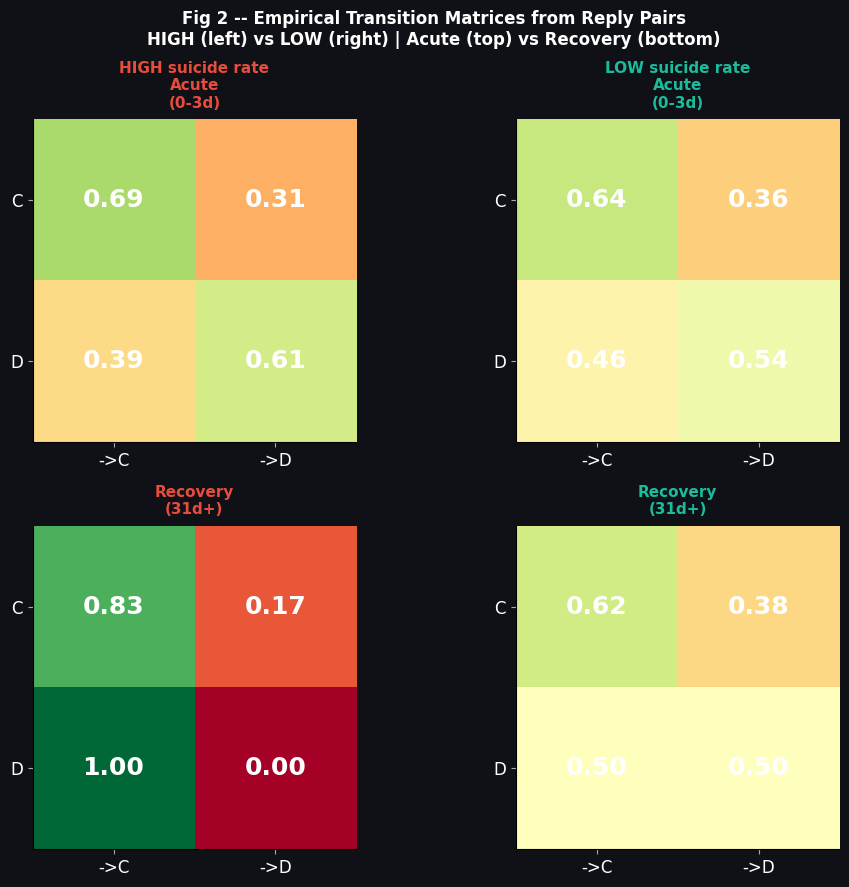

Figure 2 saved.


In [ ]:


fig, axes = plt.subplots(2,2,figsize=(10,9),facecolor="#0f1117")
fig.suptitle(
    "Fig 2 -- Empirical Transition Matrices from Reply Pairs\n"
    "HIGH (left) vs LOW (right) | Acute (top) vs Recovery (bottom)",
    fontsize=12,fontweight="bold",color="white"
)
fig.patch.set_facecolor("#0f1117")

phase_rows=[TIME_LABELS[0],TIME_LABELS[-1]]
for col_idx,grp_name in enumerate(["HIGH","LOW"]):
    for row_idx,phase in enumerate(phase_rows):
        ax=axes[row_idx][col_idx]; ax.set_facecolor("#1a1d27")
        tm=group_trans[grp_name].get(phase,np.full((2,2),0.5))
        ax.imshow(tm,cmap="RdYlGn",vmin=0,vmax=1)
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(["->C","->D"],color="white",fontsize=12)
        ax.set_yticklabels(["C","D"],color="white",fontsize=12)
        for r in range(2):
            for c in range(2):
                ax.text(c,r,f"{tm[r,c]:.2f}",ha="center",va="center",
                        color="white",fontsize=18,fontweight="bold")
        title=f"{grp_name} suicide rate\n{phase.strip()}" if row_idx==0 else phase.strip()
        ax.set_title(title,fontsize=11,fontweight="bold",color=GROUP_COLORS[grp_name],pad=8)

plt.tight_layout()
plt.savefig("fig2_group_transition_matrices_mn.png",dpi=130,bbox_inches="tight",facecolor="#0f1117")
plt.show(); print("Figure 2 saved.")


In the acute phase, high suicide-rate institutions show clear polarization: cooperative comments reinforce cooperation, but negative comments also reinforce negativity.

In contrast, low suicide-rate institutions show higher rates of conflict repair—negative comments are more likely to receive cooperative replies.

The most interesting result appears in the recovery phase. In high suicide-rate institutions, we see that negative comments almost always receive cooperative responses, and sustained conflict chains disappear.

However, this does not translate into higher overall cooperation, because new negative comments continue to emerge.

This suggests that the key difference is not how people respond to conflict, but how frequently conflict is introduced into the system.”

# IPD SIMULATION ENGINE

In [ ]:
def build_network(kind="fully_connected",n=N_AGENTS):
    if kind=="fully_connected": return nx.complete_graph(n)
    elif kind=="scale_free":    return nx.barabasi_albert_graph(n,m=3,seed=42)
    elif kind=="small_world":   return nx.watts_strogatz_graph(n,k=6,p=0.1,seed=42)

def play_round(s1,s2,h1,h2,noise=0.0):
    def move(strategy,history):
        if   strategy=="AC":   m="C"
        elif strategy=="AD":   m="D"
        elif strategy=="TFT":  m=history[-1] if history else "C"
        elif strategy=="TF2T": m="D" if (len(history)>=2 and history[-1]=="D" and history[-2]=="D") else "C"
        elif strategy=="GTFT": m=("C" if np.random.random()<0.33 else "D") if (history and history[-1]=="D") else "C"
        elif strategy=="GT":   m="D" if "D" in history else "C"
        else:                   m="C"
        if noise>0 and np.random.random()<noise: m="D" if m=="C" else "C"
        return m
    return move(s1,h1),move(s2,h2)

def payoff(m1,m2):
    return {("C","C"):(R,R),("C","D"):(S,T),("D","C"):(T,S),("D","D"):(P_pay,P_pay)}[(m1,m2)]

def run_ipd_simulation(strategies_init,G,n_generations=N_GENERATIONS,
                        n_rounds=N_ROUNDS,noise=0.0,track_strategies=None):
    if track_strategies is None: track_strategies=list(set(strategies_init))
    strategies=list(strategies_init); nodes=list(G.nodes()); history=[]
    for _ in range(n_generations):
        total_payoffs=np.zeros(len(nodes))
        for i,u in enumerate(nodes):
            for v in list(G.neighbors(u)):
                j=nodes.index(v); h_u,h_v,p_u=[],[],0
                for _ in range(n_rounds):
                    m_u,m_v=play_round(strategies[i],strategies[j],h_u,h_v,noise)
                    r_u,_=payoff(m_u,m_v); p_u+=r_u
                    h_u.append(m_v); h_v.append(m_u)
                total_payoffs[i]+=p_u
        freq={s:strategies.count(s)/len(strategies) for s in track_strategies}
        history.append(freq)
        total=total_payoffs.sum()
        probs=total_payoffs/total if total>0 else np.ones(len(nodes))/len(nodes)
        strategies=[strategies[np.random.choice(len(nodes),p=probs)] for _ in range(len(nodes))]
    return history,strategies

def compute_sim_coop(history):
    coop={"AC","TFT","TF2T","GTFT"}
    return [sum(h.get(s,0) for s in coop) for h in history]

def make_strategy_mix(c_frac,n=N_AGENTS):
    n_c=int(round(c_frac*n)); n_d=n-n_c
    mix=(["TFT"]*int(0.5*n_c)+["AC"]*int(0.3*n_c)
        +["GTFT"]*(n_c-int(0.5*n_c)-int(0.3*n_c))
        +["AD"]*int(0.6*n_d)+["GT"]*(n_d-int(0.6*n_d)))
    while len(mix)<n: mix.append("TFT")
    np.random.shuffle(mix); return mix[:n]

print("\nIPD engine ready.")



IPD engine ready.


# FIGURE 3 - BASE SIMULATION

[HIGH] init C=0.53  TFT=100  AD=0  KL=3.2559
[LOW] init C=0.46  TFT=10  AD=0  KL=0.0020


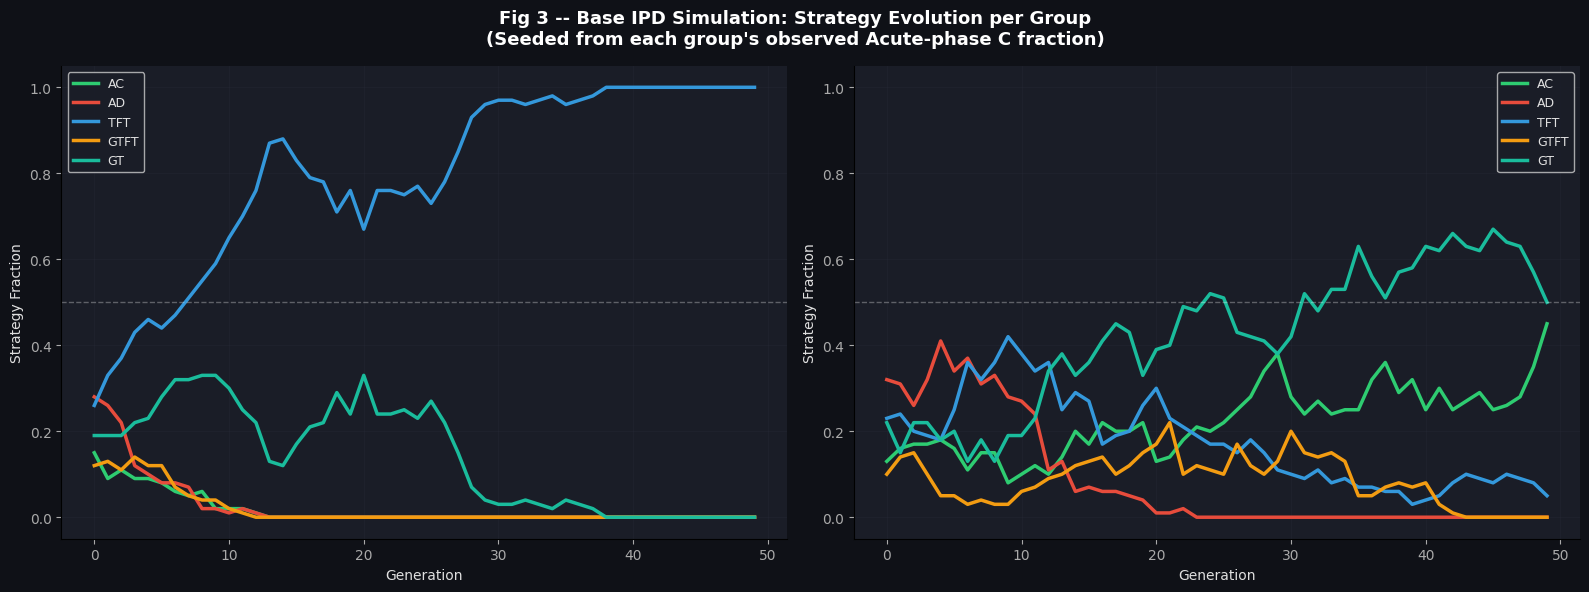

Figure 3 saved.


In [ ]:

np.random.seed(42)
strats_to_plot=["AC","AD","TFT","GTFT","GT"]
base_results={}

for grp_name in ["HIGH","LOW"]:
    c0=group_freq[grp_name].get(TIME_LABELS[0],{"C":0.5})["C"]
    mix=make_strategy_mix(c0)
    hist,final=run_ipd_simulation(mix,build_network("fully_connected"),
                                   track_strategies=strats_to_plot)
    ref_tm=list(group_trans[grp_name].values())[0]
    last_tm=list(group_trans[grp_name].values())[-1]
    kl=kl_divergence(ref_tm,last_tm)
    base_results[grp_name]={"hist":hist,"final":final,"sim_c":compute_sim_coop(hist),"c0":c0,"kl":kl}
    print(f"[{grp_name}] init C={c0:.2f}  TFT={final.count('TFT')}  AD={final.count('AD')}  KL={kl:.4f}")

fig,axes=plt.subplots(1,2,figsize=(16,6),facecolor="#0f1117")
fig.suptitle("Fig 3 -- Base IPD Simulation: Strategy Evolution per Group\n"
             "(Seeded from each group's observed Acute-phase C fraction)",
             fontsize=13,fontweight="bold",color="white")
fig.patch.set_facecolor("#0f1117")

for idx,(grp_name,res) in enumerate(base_results.items()):
    ax=axes[idx]; ax.set_facecolor("#1a1d27")
    for s in strats_to_plot:
        vals=[h.get(s,0) for h in res["hist"]]
        ax.plot(gens,vals,lw=2.5,label=s,color=COLORS[s])
    ax.set_ylim(-0.05,1.05); ax.axhline(0.5,ls="--",color="white",alpha=0.3,lw=1)
    ax.legend(fontsize=9)
    insts_lbl=" | ".join(HIGH_INSTS if grp_name=="HIGH" else LOW_INSTS)
    ax.set_title(f"{grp_name} Suicide Rate\n{insts_lbl}\n(init C={res['c0']:.2f}, KL={res['kl']:.4f})",
                 fontsize=10,fontweight="bold",color=GROUP_COLORS[grp_name])
    _ax_style(ax,"","Generation","Strategy Fraction")

plt.tight_layout()
plt.savefig("fig3_base_simulation_groups_mn.png",dpi=150,bbox_inches="tight",facecolor="#0f1117")
plt.show(); print("Figure 3 saved.")


In [ ]:
np.random.seed(1)
forgiveness_results={}

for grp_name in ["HIGH","LOW"]:
    ref_tm=list(group_trans[grp_name].values())[0]
    forgiveness_results[grp_name]={"sim_c":{},"kl":{}}
    for strat in ["TFT","TF2T","GTFT"]:
        mix=[strat]*60+["AD"]*40; np.random.shuffle(mix)
        hist,_=run_ipd_simulation(mix,build_network("fully_connected"),
                                   n_generations=N_GENERATIONS,track_strategies=[strat,"AD"])
        sim_c=compute_sim_coop(hist); c_f=sim_c[-1] if sim_c else 0.5
        sim_tm=np.array([[c_f,1-c_f],[c_f,1-c_f]])
        forgiveness_results[grp_name]["sim_c"][strat]=sim_c
        forgiveness_results[grp_name]["kl"][strat]=kl_divergence(ref_tm,sim_tm)
    kl=forgiveness_results[grp_name]["kl"]
    print(f"[{grp_name}] KL -- TFT:{kl['TFT']:.4f}  TF2T:{kl['TF2T']:.4f}  GTFT:{kl['GTFT']:.4f}")


[HIGH] KL -- TFT:4.7488  TF2T:4.7488  GTFT:5.7172
[LOW] KL -- TFT:4.6435  TF2T:4.6435  GTFT:5.7593


 # EXPERIMENT - HUB EFFECT


Hub node: 4  degree: 30
[HIGH] AD@hub -> TFT=100  AD=0
[LOW] AD@hub -> TFT=100  AD=0


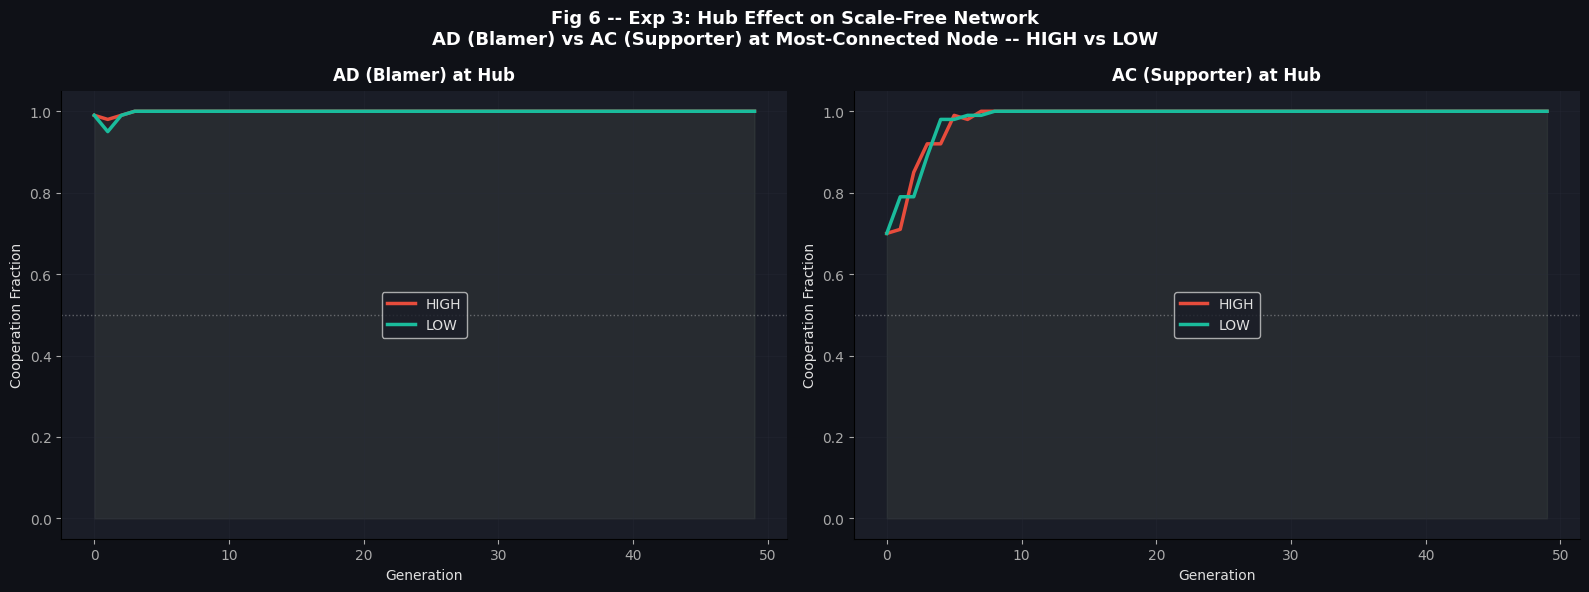

Figure 6 saved.


In [ ]:
np.random.seed(2)
G_sf=build_network("scale_free"); nodes_sf=list(G_sf.nodes())
hub=max(dict(G_sf.degree()),key=lambda k:G_sf.degree(k)); hub_idx=nodes_sf.index(hub)
print(f"\nHub node: {hub}  degree: {G_sf.degree(hub)}")

hub_results={}
for grp_name in ["HIGH","LOW"]:
    s_ad=["TFT"]*N_AGENTS; s_ad[hub_idx]="AD"
    hist_ad,final_ad=run_ipd_simulation(s_ad,G_sf,n_generations=N_GENERATIONS,
                                         track_strategies=["TFT","AD"])
    s_ac=["TFT"]*70+["AD"]*30; np.random.shuffle(s_ac); s_ac[hub_idx]="AC"
    hist_ac,final_ac=run_ipd_simulation(s_ac,G_sf,n_generations=N_GENERATIONS,
                                         track_strategies=["TFT","AD","AC"])
    hub_results[grp_name]={
        "ad":{"sim_c":compute_sim_coop(hist_ad),"final":final_ad},
        "ac":{"sim_c":compute_sim_coop(hist_ac),"final":final_ac},
    }
    print(f"[{grp_name}] AD@hub -> TFT={final_ad.count('TFT')}  AD={final_ad.count('AD')}")

fig,axes=plt.subplots(1,2,figsize=(16,6),facecolor="#0f1117")
fig.suptitle("Fig 6 -- Exp 3: Hub Effect on Scale-Free Network\n"
             "AD (Blamer) vs AC (Supporter) at Most-Connected Node -- HIGH vs LOW",
             fontsize=13,fontweight="bold",color="white")
fig.patch.set_facecolor("#0f1117")

for ax_idx,(hub_type,hub_label) in enumerate([("ad","AD (Blamer) at Hub"),
                                               ("ac","AC (Supporter) at Hub")]):
    ax=axes[ax_idx]; ax.set_facecolor("#1a1d27")
    for grp_name,res in hub_results.items():
        ax.plot(gens,res[hub_type]["sim_c"],lw=2.5,label=f"{grp_name}",
                color=GROUP_COLORS[grp_name])
        ax.fill_between(gens,res[hub_type]["sim_c"],alpha=0.07,color=GROUP_COLORS[grp_name])
    ax.axhline(0.5,ls=":",color="white",alpha=0.3,lw=1)
    ax.set_ylim(-0.05,1.05); ax.legend(fontsize=10)
    _ax_style(ax,hub_label,"Generation","Cooperation Fraction")

plt.tight_layout()
plt.savefig("fig6_hub_effect_groups_mn.png",dpi=150,bbox_inches="tight",facecolor="#0f1117")
plt.show(); print("Figure 6 saved.")


# STRATEGY MIXTURE FITTING theta*


[HIGH] theta* (MSE=0.00910):
  AC: 0.018
  AD: 0.385
  TFT: 0.288
  TF2T: 0.102
  GTFT: 0.082
  GT: 0.124

[LOW] theta* (MSE=0.00381):
  AC: 0.076
  AD: 0.215
  TFT: 0.113
  TF2T: 0.018
  GTFT: 0.248
  GT: 0.330


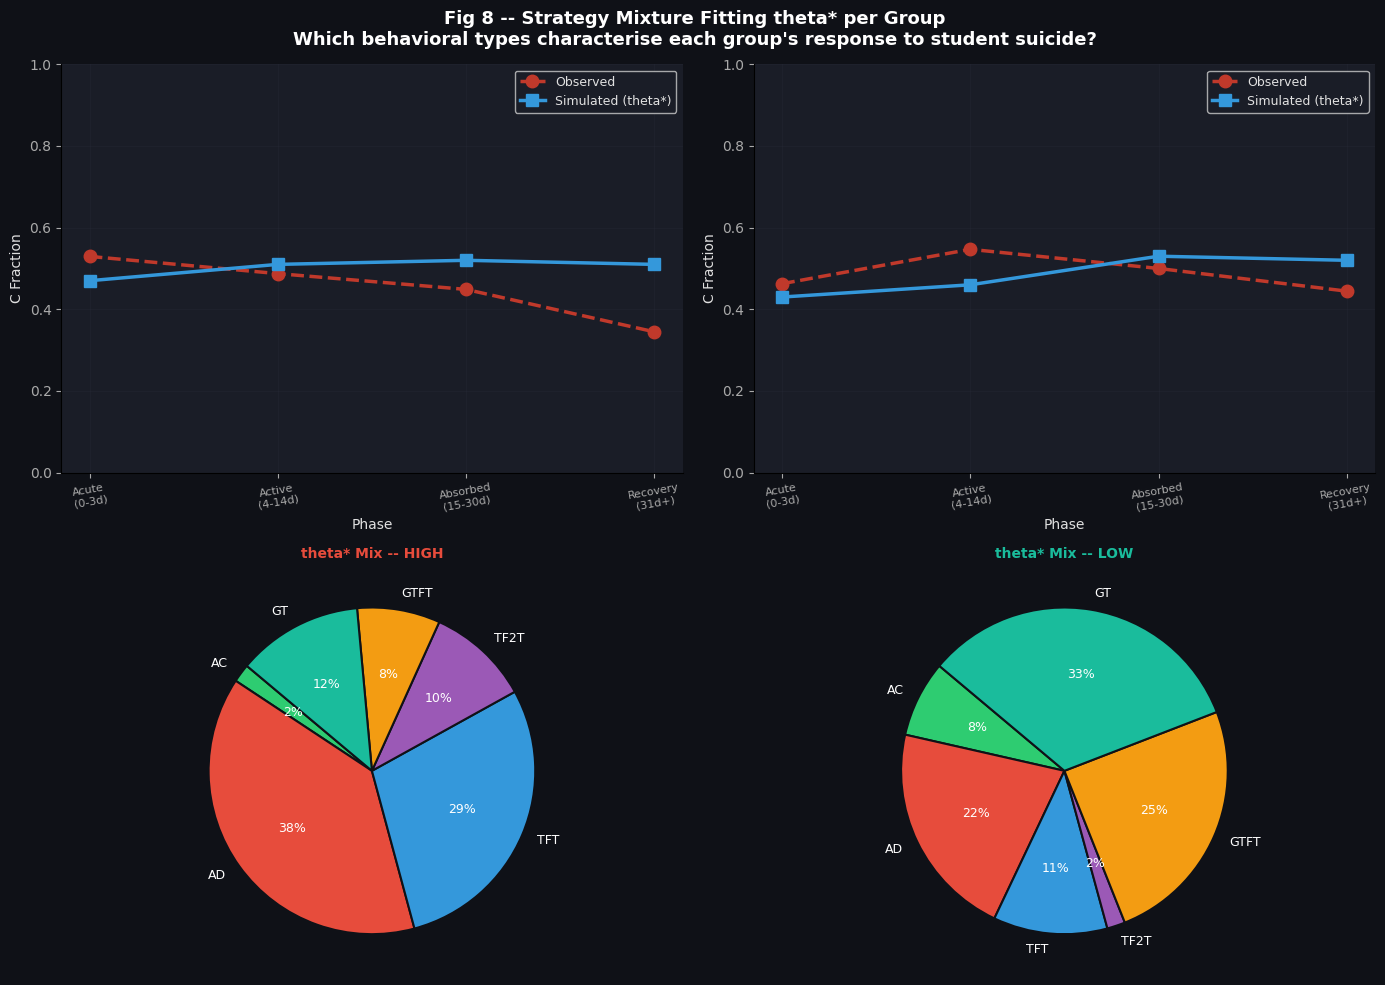

Figure 8 saved.


In [ ]:
def fit_strategy_mix(obs_c_fracs,candidate_strategies,G,n_trials=15):
    best_mse,best_theta,best_history=np.inf,None,None
    for _ in range(n_trials):
        theta=np.random.dirichlet(np.ones(len(candidate_strategies)))
        counts=(theta*N_AGENTS).astype(int); counts[-1]=N_AGENTS-counts[:-1].sum()
        strats=[]
        for s,c in zip(candidate_strategies,counts): strats.extend([s]*max(0,c))
        strats=(strats+[candidate_strategies[0]]*N_AGENTS)[:N_AGENTS]
        np.random.shuffle(strats)
        hist,_=run_ipd_simulation(strats,G,n_generations=N_GENERATIONS,
                                   track_strategies=candidate_strategies)
        sim_c=compute_sim_coop(hist); n=min(len(obs_c_fracs),len(sim_c))
        mse=np.mean((np.array(obs_c_fracs[:n])-np.array(sim_c[:n]))**2)
        if mse<best_mse: best_mse,best_theta,best_history=mse,theta,hist
    return best_theta,best_mse,best_history

np.random.seed(42)
candidate_strats=["AC","AD","TFT","TF2T","GTFT","GT"]
fit_results={}

for grp_name in ["HIGH","LOW"]:
    obs_c=[group_freq[grp_name].get(b,{"C":0.5})["C"] for b in TIME_LABELS]
    theta,mse,hist_fit=fit_strategy_mix(obs_c,candidate_strats,build_network("fully_connected"))
    fit_results[grp_name]={"theta":theta,"mse":mse,"hist":hist_fit,"obs_c":obs_c}
    print(f"\n[{grp_name}] theta* (MSE={mse:.5f}):")
    for s,w in zip(candidate_strats,theta): print(f"  {s}: {w:.3f}")

pie_colors=[COLORS.get(s,"#cccccc") for s in candidate_strats]

fig,axes=plt.subplots(2,2,figsize=(14,10),facecolor="#0f1117")
fig.suptitle("Fig 8 -- Strategy Mixture Fitting theta* per Group\n"
             "Which behavioral types characterise each group's response to student suicide?",
             fontsize=13,fontweight="bold",color="white")
fig.patch.set_facecolor("#0f1117")

for col_idx,grp_name in enumerate(["HIGH","LOW"]):
    res=fit_results[grp_name]; sim_c=compute_sim_coop(res["hist"]); obs_c=res["obs_c"]
    ax=axes[0][col_idx]; ax.set_facecolor("#1a1d27")
    n=min(len(obs_c),len(sim_c),len(TIME_LABELS))
    ax.plot(range(n),obs_c[:n],"o--",lw=2.5,color=COLORS["D"],label="Observed",markersize=9)
    ax.plot(range(n),sim_c[:n],"s-",lw=2.5,color=COLORS["TFT"],label="Simulated (theta*)",markersize=9)
    ax.set_xticks(range(n)); ax.set_xticklabels(TIME_LABELS[:n],fontsize=8,rotation=10)
    ax.set_ylim(0,1); ax.legend(fontsize=9)
    ax.set_title(f"{grp_name} Suicide Rate -- MSE={res['mse']:.4f}",
                 fontsize=11,fontweight="bold",color=GROUP_COLORS[grp_name])
    _ax_style(ax,"","Phase","C Fraction")
    ax2=axes[1][col_idx]; ax2.set_facecolor("#0f1117")
    wedges,texts,autotexts=ax2.pie(
        res["theta"],labels=candidate_strats,colors=pie_colors,
        autopct="%1.0f%%",startangle=140,
        textprops={"color":"white","fontsize":9},
        wedgeprops={"edgecolor":"#0f1117","linewidth":1.5}
    )
    for at in autotexts: at.set_color("white"); at.set_fontsize(9)
    ax2.set_title(f"theta* Mix -- {grp_name}",fontsize=10,fontweight="bold",
                  color=GROUP_COLORS[grp_name])

plt.tight_layout()
plt.savefig("fig8_mixture_fitting_groups_mn.png",dpi=150,bbox_inches="tight",facecolor="#0f1117")
plt.show(); print("Figure 8 saved.")

# FIGURE 9 - SUMMARY HEATMAP


-- SUMMARY TABLE --
       base_KL  forgive_TFT  forgive_TF2T  forgive_GTFT  fit_MSE
group                                                           
HIGH    3.2559       4.7488        4.7488        5.7172   0.0091
LOW     0.0020       4.6435        4.6435        5.7593   0.0038


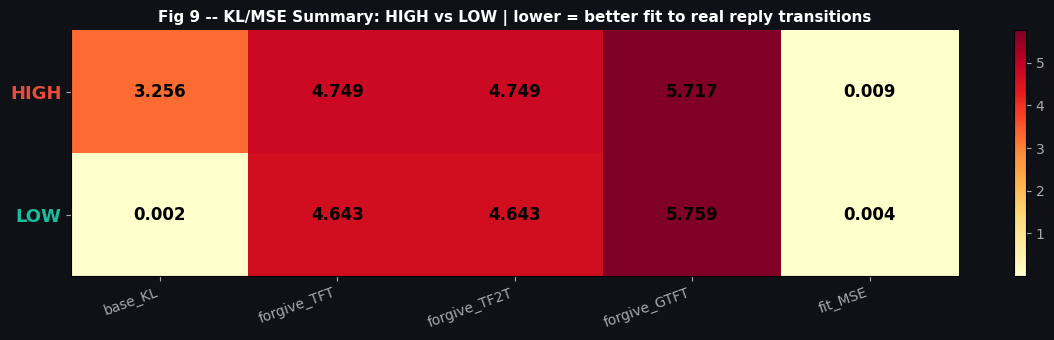

Figure 9 saved.


In [ ]:
summary_rows=[]
for grp_name in ["HIGH","LOW"]:
    row={"group":grp_name,
         "base_KL":base_results[grp_name]["kl"],
         "forgive_TFT":forgiveness_results[grp_name]["kl"]["TFT"],
         "forgive_TF2T":forgiveness_results[grp_name]["kl"]["TF2T"],
         "forgive_GTFT":forgiveness_results[grp_name]["kl"]["GTFT"],
         "fit_MSE":fit_results[grp_name]["mse"]}
    summary_rows.append(row)

summary_df=pd.DataFrame(summary_rows).set_index("group")
print("\n-- SUMMARY TABLE --"); print(summary_df.round(4).to_string())

fig,ax=plt.subplots(figsize=(12,3.5),facecolor="#0f1117")
fig.patch.set_facecolor("#0f1117"); ax.set_facecolor("#1a1d27")
data=summary_df.values.astype(float); im=ax.imshow(data,cmap="YlOrRd",aspect="auto")
ax.set_xticks(range(len(summary_df.columns)))
ax.set_xticklabels(summary_df.columns,rotation=20,ha="right",fontsize=10)
ax.set_yticks(range(len(summary_df.index)))
ax.set_yticklabels(summary_df.index,fontsize=13,fontweight="bold")
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val=data[i,j]
        if not np.isnan(val):
            ax.text(j,i,f"{val:.3f}",ha="center",va="center",
                    color="black",fontsize=12,fontweight="bold")
for tick,grp_name in zip(ax.get_yticklabels(),summary_df.index):
    tick.set_color(GROUP_COLORS[grp_name])
plt.colorbar(im,ax=ax)
ax.set_title("Fig 9 -- KL/MSE Summary: HIGH vs LOW | lower = better fit to real reply transitions",
             fontsize=11,fontweight="bold",color="white")
plt.tight_layout()
plt.savefig("fig9_summary_heatmap_groups_mn.png",dpi=150,bbox_inches="tight",facecolor="#0f1117")
plt.show(); print("Figure 9 saved.")